# EJERCICIO 18



## 18 a

# Generador de congruencias lineales para generar numeros pseudoaleatorios 

Vamos a escribir una funcion que nos permita generar numeros pseudoaleatorios a partir de la congruencia lineal. Para esto nos vamos a ayudar de lo siguiente:

$X_{n+1} = (aX_n + c)mod(m)$

Esta formula recursiva de congruencia lineal, nos permitira generar numeros aleatorios, a partir de seleccionar cuidadosamente los parametros que la definen.

Necesitamos calcular mod, para esto vamos a utilizar numpy que trae incorporado mod.

El periodo de los numeros generados es: 256


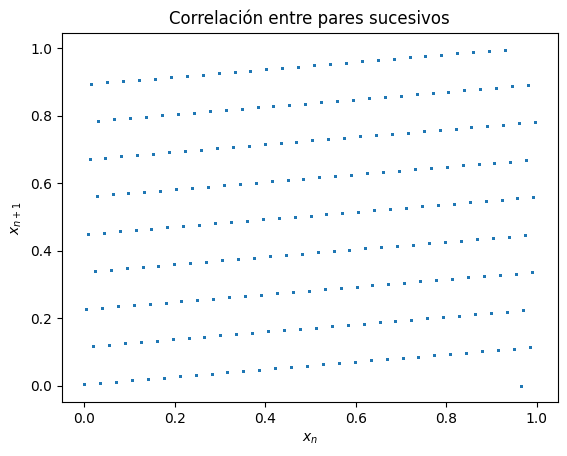

In [1]:
#primero importamos las librerias que vamos a usar

import numpy as np
import matplotlib.pyplot as plt


#---------------------------------------------------------------------

#definimos la funcion que va a generar los numeros, esta funcion recibe como parametros (a,c,M,X1,n), donde a,c,M son los parametros del generador congruencial lineal, X1 es la semilla, y n es la cantidad de numeros que queremos generar

def generador_congruencia_lineal(a,c,M,X1,n): 
    numeros = []                     
    x = X1                          
    for i in range(n):   
        x = (a*x + c) % M            
        numeros.append(x/M)          
    return numeros                   

#ahora, la funcion esta definida, y podemos usarla, para esto le pasamos los parametros que necesita (a,c,M,X1,n) = 57,1,256,34,10, notemos que n es la cantidad de numeros que queremos generar    

a=57
c=1
M=256
X1=34
n=10000

#ahora vamos a generar los numeros

numeros_generados = generador_congruencia_lineal(a,c,M,X1,n) 


#---------------------------------------------------------------------


#ahora, si queremos calcular el periodo de los numeros generados, es decir, cada cuantas veces se repiten los numeros, podemos hacer lo siguiente:

def calcular_periodo(numeros):     
    vistos = {}                
    for i, valor in enumerate(numeros): #iteramos sobre la lista de numeros, usando enumerate para tener el indice y el valor
        if valor in vistos:             #si el valor ya lo vimos antes, entonces el periodo es la diferencia entre el indice actual y el indice donde lo vimos por primera vez
            return i - vistos[valor]    #devolvemos el periodo
        vistos[valor] = i               #si no lo vimos antes, lo guardamos en el diccionario con su indice
    return None                      

#muy bien, ya tenemos nuestra funcion para calcular periodo definida, ahora la podemos utilizar y para esto le pasamos la lista de numeros generados a una nueva variable y hacemos print del resultado

periodo = calcular_periodo(numeros_generados)
print(f'El periodo de los numeros generados es: {periodo}')



#----------------------------------------------------------------------

#pares de numeros sucesivos
plt.scatter(numeros_generados[:-1], numeros_generados[1:], s=1) #usamos plt.scatter para hacer un diagrama de dispersion, en el eje x ponemos todos los numeros menos el ultimo (numeros[:-1]) y en el eje y ponemos todos los numeros menos el primero (numeros[1:]), esto nos da pares de numeros sucesivos, y usamos s=1 para que los puntos sean mas pequeños
plt.title('Correlación entre pares sucesivos')
plt.xlabel('$x_n$')
plt.ylabel('$x_{n+1}$')
plt.show()





## Al parecer no se dispersan como deberian, podemos mejorar esto cambiando las constantes con valores conocidos en donde se sabe que funciona mejor este metodo!!

El periodo de los numeros generados es: None


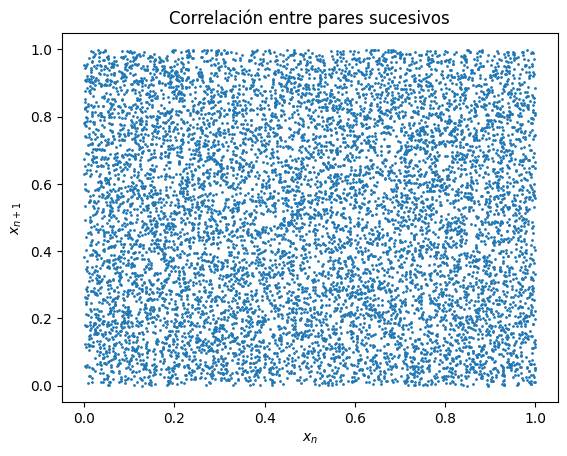

In [2]:
import numpy as np
import matplotlib.pyplot as plt


def generador_congruencia_lineal(a,c,M,X1,n): 
    numeros = []                     
    x = X1                           
    for i in range(n):           
        x = (a*x + c) % M    
        numeros.append(x/M)          
    return numeros                   


# ahora pasamos los parametros nuevos

a = 1664525
c = 1013904223
M = 2**32
X1 = 10
n = 10000

#generamos los numeros

numeros_generados = generador_congruencia_lineal(a,c,M,X1,n) #aca estamos definiendo una variable numeros_generados, que va a guardar el resultado de la funcion que definimos arriba, y le pasamos los parametros que necesita


#---------------------------------------------------------------------


#definimos la funcion para calcular el periodo

def calcular_periodo(numeros): 
    vistos = {}                
    for i, valor in enumerate(numeros):  
        if valor in vistos:             
            return i - vistos[valor]    
        vistos[valor] = i               
    return None                       

#calculamos el periodo

periodo = calcular_periodo(numeros_generados)
print(f'El periodo de los numeros generados es: {periodo}')



#----------------------------------------------------------------------

#pares de numeros sucesivos
plt.scatter(numeros_generados[:-1], numeros_generados[1:], s=1) #usamos plt.scatter para hacer un diagrama de dispersion, en el eje x ponemos todos los numeros menos el ultimo (numeros[:-1]) y en el eje y ponemos todos los numeros menos el primero (numeros[1:]), esto nos da pares de numeros sucesivos, y usamos s=1 para que los puntos sean mas pequeños
plt.title('Correlación entre pares sucesivos')
plt.xlabel('$x_n$')
plt.ylabel('$x_{n+1}$')
plt.show()

Funciono muy bien!! ahora, vamos con lo que sigue:

## Momentos de orden K
nos piden evaluar el momento de orden k (k=1, 3 y 7) de la distribucion de (N=10, 100 y 1000) numeros obtenida, y comparar con $\frac{1}{k+1}$ .

In [3]:
import numpy as np

# Momentos de orden k
def calcular_momentos(numeros_generados, k):
    momentos = [np.mean((np.array(numeros_generados)) ** i) for i in k] #aca estamos usando una lista por comprension, que es una forma rapida de crear listas en python. Lo que hacemos es tomar la lista de numeros generados, la convertimos en un array de numpy (np.array(numeros_generados)), y luego elevamos cada elemento del array a la potencia i (donde i toma los valores de la lista k), y luego calculamos el promedio de esos valores elevados a la potencia i (np.mean(...)). Esto lo hacemos para cada valor de i en k, y guardamos los resultados en la lista momentos.
    return momentos #devolvemos la lista de momentos calculados

# Parámetros
k = [1,3,7] #ordenes de los momentos que queremos calcular
momentos = calcular_momentos(numeros_generados, k) #aca estamos definiendo una variable momentos, que va a guardar el resultado de la funcion que definimos arriba, y le pasamos los parametros que necesita
print(f'Momentos de orden k = {k} para n = {n}: {momentos}') #aca imprimimos el resultado, notemos que usamos f'' para poder meter la variable dentro del string que queremos imprimir

#momentos teoricos

y = 1 / (np.array(k) + 1)
print(f'Momentos teóricos de orden k = {k}: {y}')


Momentos de orden k = [1, 3, 7] para n = 10000: [np.float64(0.4974137784881517), np.float64(0.24835483642043638), np.float64(0.12363195594196229)]
Momentos teóricos de orden k = [1, 3, 7]: [0.5   0.25  0.125]


# EJERCICIO 18b

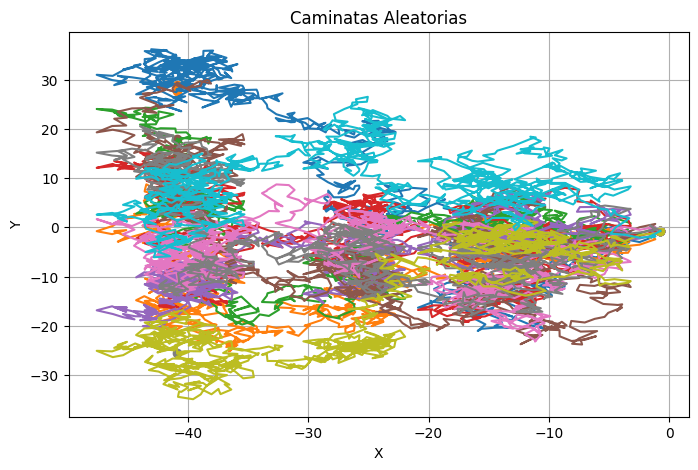

In [4]:
import numpy as np  
import matplotlib.pyplot as plt 

#Generamos numeros aleatorios con congruencia lineal

def generador_congruencia_lineal(a,c,M,X1,n): 
    numeros = []                     
    x = X1                           
    for i in range(n):               
        x = (a*x + c) % M            
        numeros.append(x/M)          
    return np.array(numeros) #devolvemos un array de numpy en lugar de una lista                   


# Parámetros

a = 1664525
c = 1013904223
M = 2**32
X1 = 10
n = 1000      #numero de pasos
K = 10        #cantidad de caminatas 


# Función para realizar una caminata aleatoria usando nuestro generador

def caminata_aleatoria(a,c,M,X1,n,k):
    pasos = [] 

    for j in range(k):
        dx = []
        dy = []
        x  = generador_congruencia_lineal(a,c,M,X1,n) #generamos n numeros aleatorios
        y  = generador_congruencia_lineal(a,c,M,X1+j +1 ,n) #generamos n numeros aleatorios, pero con una semilla diferente para que no sean iguales a los de x
        for i in range(n):
            dx.append(2 * (x[i] - 0.5) * np.sqrt(2)) #transformamos los numeros generados para que esten entre -sqrt(2) y sqrt(2)   
            dy.append(2 * (y[i] - 0.5) * np.sqrt(2))
        X = np.cumsum(dx) # Posiciones acumuladas
        Y = np.cumsum(dy)
        pasos.append((X, Y)) 
    return pasos


# generamos las caminatas
caminata = caminata_aleatoria(a, c, M, X1, n, K)


# ahora graficamos las caminatas

plt.figure(figsize=(8, 5))
for i, (X, Y) in enumerate(caminata):
    plt.plot(X, Y)
    plt.scatter(X[0], Y[0])
    plt.scatter(X[-1], Y[-1])
plt.title(f'Caminatas Aleatorias')
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(True)
plt.show()
        

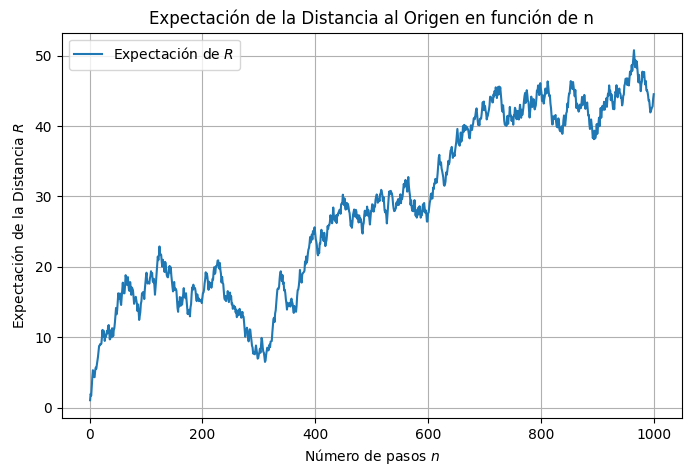

In [5]:
# calculamos el valor de expectación de la distancia al origen en función de N


#definimos la funcion 
def expectacion_distancia_por_paso(caminata, n):
    R = []
    for l in range(1, n+1):
        distancias = [np.sqrt(X[l-1]**2 + Y[l-1]**2) for (X, Y) in caminata]
        R.append(np.mean(distancias))
    return R


# Calculamos y graficamos la expectación de la distancia al origen para cada paso n
R_por_paso = expectacion_distancia_por_paso(caminata, n)

plt.figure(figsize=(8, 5))
plt.plot(range(1, n+1), R_por_paso, label='Expectación de $R$')
plt.title('Expectación de la Distancia al Origen en función de n')
plt.xlabel('Número de pasos $n$')
plt.ylabel('Expectación de la Distancia $R$')
plt.grid(True)
plt.legend()
plt.show()

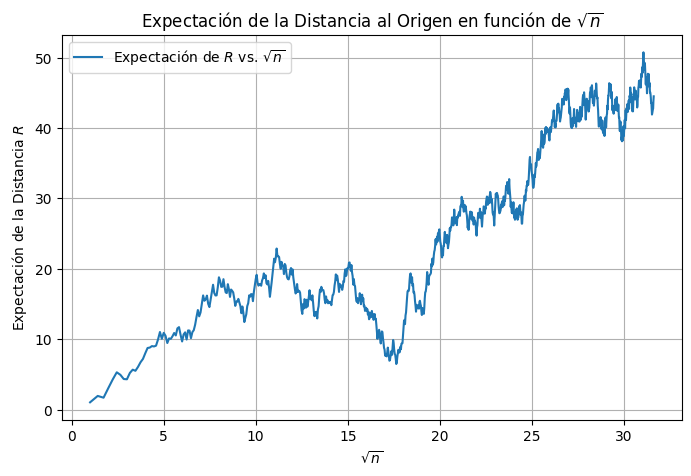

In [6]:
# Calculamos y graficamos la expectación de la distancia al origen en función de la raíz de n
R_por_paso = expectacion_distancia_por_paso(caminata, n)

plt.figure(figsize=(8, 5))
plt.plot(np.sqrt(np.arange(1, n+1)), R_por_paso, label='Expectación de $R$ vs. $\\sqrt{n}$')
plt.title('Expectación de la Distancia al Origen en función de $\\sqrt{n}$')
plt.xlabel('$\\sqrt{n}$')
plt.ylabel('Expectación de la Distancia $R$')
plt.grid(True)
plt.legend()
plt.show()